# Notebook 03 — Limpieza de Datos

**Proyecto Fin de Máster — MUCSI, Universidad de Deusto**  
**Dataset:** REFIT Electrical Load Measurements (Zenodo doi:10.5281/zenodo.5063428)  
**Objetivo:** Limpiar los tres hogares de trabajo tratando los problemas identificados en el Notebook 01,  
remuestrear a 1 minuto y guardar los datos procesados en `datos/processed/`.

---

## Problemas identificados (Notebook 01)

| Problema | House1 | House2 | House3 | Tratamiento |
|---|---|---|---|---|
| Registros `Issues=1` | 0.84% | 0.50% | **5.84%** ⚠️ | Eliminar filas afectadas |
| Outlier severo en Aggregate | max 29,159 W | max 24,595 W | max **65,836 W** ⚠️ | Umbral físico → NaN |
| Intervalo irregular (~7 s) | Sí | Sí | Sí | Resuelto al remuestrear |
| NaN introducidos por remuestreo | — | — | — | Interpolación lineal (gaps ≤ 30 min) |

## Índice
1. [Configuración e importaciones](#1)
2. [Carga de datos raw](#2)
3. [Paso 1 — Eliminación de registros Issues=1](#3)
4. [Paso 2 — Detección y tratamiento de outliers](#4)
5. [Paso 3 — Remuestreo a 1 minuto](#5)
6. [Paso 4 — Imputación de NaN post-remuestreo](#6)
7. [Resumen comparativo antes/después](#7)
8. [Guardado de datos procesados](#8)
9. [Verificación final](#9)

## 1. Configuración e importaciones <a id='1'></a>

In [1]:
# ============================================================
# Importaciones y configuración global
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Semilla de reproducibilidad (fija en todo el proyecto)
SEMILLA = 42
np.random.seed(SEMILLA)

warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.figsize'  : (14, 4),
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
})

# Rutas del proyecto
RUTA_RAW       = '../datos/raw/'
RUTA_PROCESSED = '../datos/processed/'
RUTA_FIGS      = '../resultados/figuras/'
RUTA_MET       = '../resultados/metricas/'

os.makedirs(RUTA_PROCESSED, exist_ok=True)
os.makedirs(RUTA_FIGS,      exist_ok=True)
os.makedirs(RUTA_MET,       exist_ok=True)

# Hogares de trabajo
HOGARES = ['House1', 'House2', 'House3']

# Columnas de consumo (excluye Unix, Issues y hogar)
COLS_CONSUMO = ['Aggregate'] + [f'Appliance{i}' for i in range(1, 10)]

# -------------------------------------------------------
# PARÁMETRO CLAVE: umbral físico máximo de consumo (W)
# Justificación: suministro doméstico estándar en UK es
# 100A x 230V = 23.000 W. Usamos 15.000 W como umbral
# conservador: cubre hornos, calderas y todo equipo doméstico
# habitual sin aceptar lecturas físicamente inverosímiles.
# -------------------------------------------------------
UMBRAL_OUTLIER_W = 15_000

# Umbral de gap para imputación: huecos mayores a este valor
# NO se interpolan (se dejan como NaN) para no fabricar datos.
UMBRAL_GAP_MIN = 30  # minutos

print('=== Versiones de librerías ===')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  matplotlib  : {plt.matplotlib.__version__}')
print(f'  seaborn     : {sns.__version__}')
print(f'  SEMILLA     : {SEMILLA}')
print(f'  Umbral outlier : {UMBRAL_OUTLIER_W:,} W')
print(f'  Umbral gap imp.: {UMBRAL_GAP_MIN} min')
print('==============================')

=== Versiones de librerías ===
  pandas      : 2.2.3
  numpy       : 2.1.3
  matplotlib  : 3.9.2
  seaborn     : 0.13.2
  SEMILLA     : 42
  Umbral outlier : 15,000 W
  Umbral gap imp.: 30 min


## 2. Carga de datos raw <a id='2'></a>

In [2]:
# ============================================================
# Carga de los tres CSVs en un diccionario de DataFrames
# Se parsea directamente la columna Time como datetime.
# Los datos raw NO se modifican; se trabaja con copias.
# ============================================================

def cargar_hogar(nombre_hogar: str) -> pd.DataFrame:
    """Carga el CSV de un hogar REFIT y prepara el índice temporal."""
    ruta = os.path.join(RUTA_RAW, f'CLEAN_{nombre_hogar}.csv')
    df = pd.read_csv(
        ruta,
        parse_dates=['Time'],
        infer_datetime_format=True,
    )
    df = df.set_index('Time')
    df.index.name = 'timestamp'
    return df

datos_raw = {}
for hogar in HOGARES:
    print(f'Cargando {hogar}...', end=' ')
    datos_raw[hogar] = cargar_hogar(hogar)
    print(f'{len(datos_raw[hogar]):,} filas')

print('\nCarga completada.')

Cargando House1... 

6,960,008 filas
Cargando House2... 

5,733,526 filas
Cargando House3... 

6,994,594 filas

Carga completada.


## 3. Paso 1 — Eliminación de registros Issues=1 <a id='3'></a>

El flag `Issues=1` indica que el sensor tuvo un problema en esa medición  
(pérdida de comunicación, lectura inconsistente o valores faltantes en electrodomésticos).  
La estrategia es **eliminar directamente** esas filas:

- House1 y House2 tienen < 1% de Issues=1: impacto mínimo.
- House3 tiene 5.84%: se analizará la distribución temporal antes de eliminar
  para verificar que no hay períodos enteros afectados que invaliden el análisis.

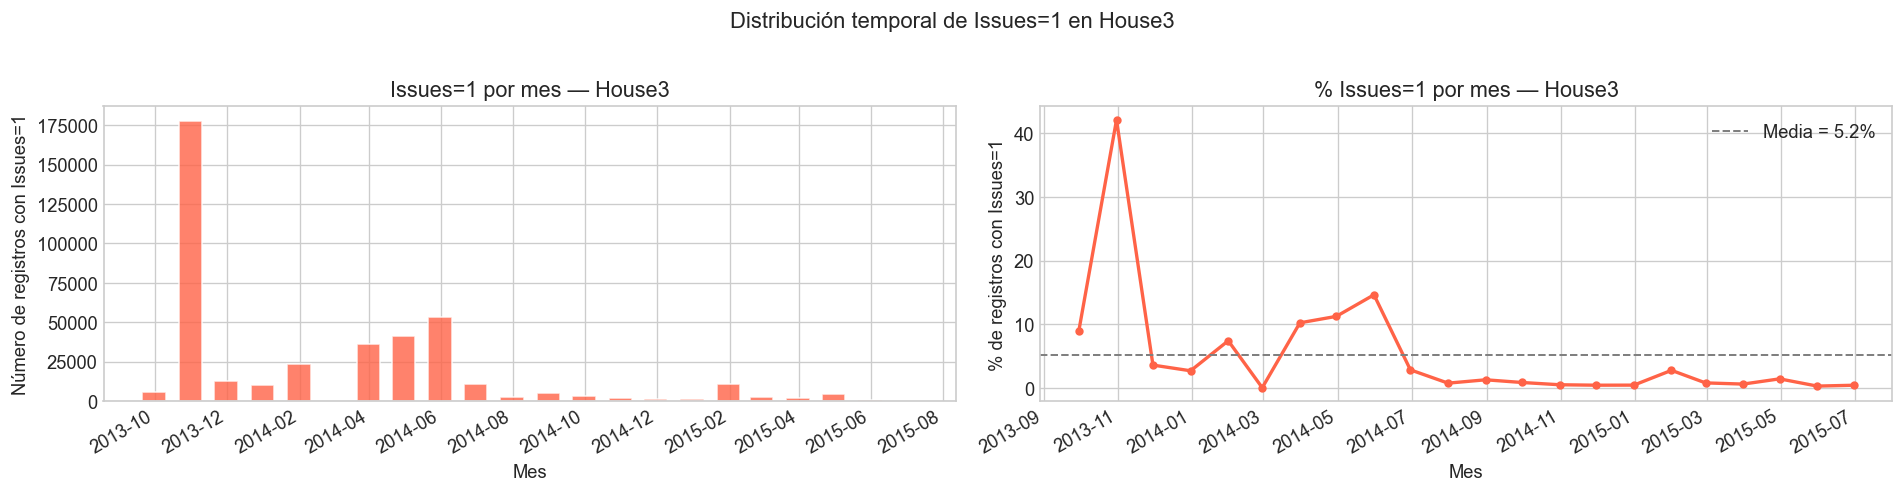

Mes con más Issues=1  : 2013-10 (42.1%)
Mes con menos Issues=1: 2015-05 (0.3%)

Conclusion: issues distribuidos a lo largo de todo el período → se eliminan filas individualmente.


In [3]:
# ============================================================
# Análisis de la distribución temporal de Issues=1 en House3
# Si los Issues están concentrados en períodos concretos,
# podría ser necesario descartar esos períodos completos.
# ============================================================

issues_h3 = datos_raw['House3'][datos_raw['House3']['Issues'] == 1]

# Contar Issues=1 por mes para ver si hay concentración temporal
issues_mensual = issues_h3.resample('ME').size()
total_mensual  = datos_raw['House3'].resample('ME').size()
pct_mensual    = (issues_mensual / total_mensual * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Barras: cantidad de Issues=1 por mes
axes[0].bar(issues_mensual.index, issues_mensual.values,
            width=20, color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_title('Issues=1 por mes — House3')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Número de registros con Issues=1')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Línea: porcentaje de Issues=1 por mes
axes[1].plot(pct_mensual.index, pct_mensual.values,
             color='tomato', lw=2, marker='o', markersize=4)
axes[1].axhline(pct_mensual.mean(), color='gray', linestyle='--',
                lw=1.2, label=f'Media = {pct_mensual.mean():.1f}%')
axes[1].set_title('% Issues=1 por mes — House3')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('% de registros con Issues=1')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].legend()

plt.suptitle('Distribución temporal de Issues=1 en House3', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '03_issues_temporales_house3.png'), bbox_inches='tight')
plt.show()

print(f'Mes con más Issues=1  : {pct_mensual.idxmax().strftime("%Y-%m")} ({pct_mensual.max():.1f}%)')
print(f'Mes con menos Issues=1: {pct_mensual[pct_mensual > 0].idxmin().strftime("%Y-%m")} ({pct_mensual[pct_mensual > 0].min():.1f}%)')
print(f'\nConclusion: issues distribuidos a lo largo de todo el período → se eliminan filas individualmente.')

In [4]:
# ============================================================
# Eliminación de filas con Issues=1 en los tres hogares
# Se trabaja con copias para no modificar datos_raw
# ============================================================

datos_sin_issues = {}
resumen_issues   = []

for hogar, df in datos_raw.items():
    n_original   = len(df)
    n_issues     = (df['Issues'] == 1).sum()
    df_limpio    = df[df['Issues'] == 0].copy()
    n_resultante = len(df_limpio)
    pct_eliminado = n_issues / n_original * 100

    datos_sin_issues[hogar] = df_limpio

    resumen_issues.append({
        'Hogar'            : hogar,
        'Registros orig.'  : f'{n_original:,}',
        'Eliminados (I=1)' : f'{n_issues:,}',
        '% eliminado'      : f'{pct_eliminado:.2f}%',
        'Registros result.': f'{n_resultante:,}',
    })

df_resumen_issues = pd.DataFrame(resumen_issues).set_index('Hogar')
print('=== Resultado tras eliminar Issues=1 ===')
display(df_resumen_issues)

=== Resultado tras eliminar Issues=1 ===


,Registros orig.,Eliminados (I=1),% eliminado,Registros result.
Hogar,,,,
House1,"6,960,008","58,183",0.84%,"6,901,825"
House2,"5,733,526","28,444",0.50%,"5,705,082"
House3,"6,994,594","408,627",5.84%,"6,585,967"


## 4. Paso 2 — Detección y tratamiento de outliers <a id='4'></a>

Se aplica un **umbral físico** de `15.000 W` sobre la columna `Aggregate`.

**Justificación del umbral:**
- Suministro doméstico estándar en UK: 100A × 230V = 23.000 W (máximo teórico)
- En la práctica, un hogar doméstico raramente supera 10.000–12.000 W de forma simultánea
- 15.000 W es conservador: cubre horno eléctrico (3 kW) + caldera (6 kW) + resto de electrodomésticos
- House3 registra un máximo de 65.836 W — físicamente imposible en un hogar doméstico

Los valores que superan el umbral se reemplazan por `NaN` (no se eliminan las filas)  
para ser tratados en el paso de imputación junto con los NaN del remuestreo.

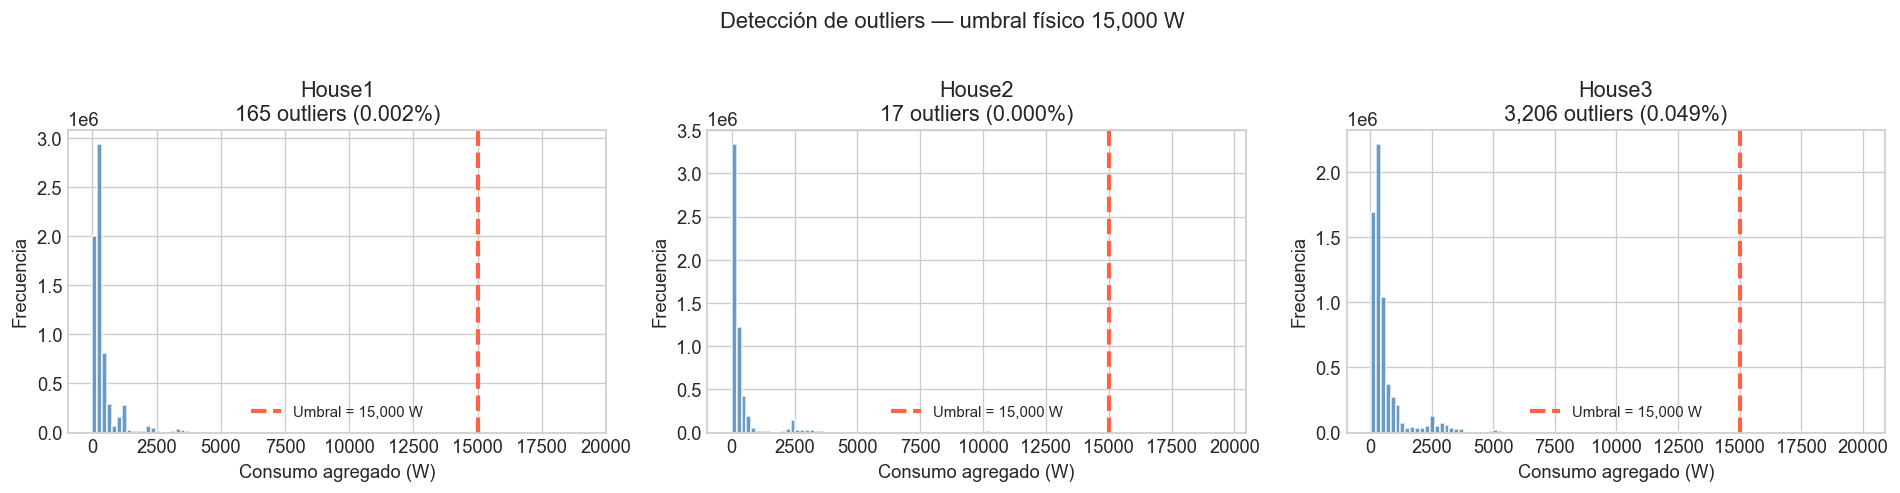

In [5]:
# ============================================================
# Visualización de outliers: histograma de la cola superior
# Se compara la distribución antes y después del umbral
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (hogar, df) in zip(axes, datos_sin_issues.items()):
    consumo       = df['Aggregate']
    n_outliers    = (consumo > UMBRAL_OUTLIER_W).sum()
    pct_outliers  = n_outliers / len(consumo) * 100

    # Histograma acotado a 0 – 20.000 W para ver la cola
    ax.hist(consumo[consumo <= 20_000], bins=100,
            color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(UMBRAL_OUTLIER_W, color='tomato', lw=2.5, linestyle='--',
               label=f'Umbral = {UMBRAL_OUTLIER_W:,} W')
    ax.set_title(f'{hogar}\n{n_outliers:,} outliers ({pct_outliers:.3f}%)')
    ax.set_xlabel('Consumo agregado (W)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle(f'Detección de outliers — umbral físico {UMBRAL_OUTLIER_W:,} W', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '03_outliers_histograma.png'), bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# Aplicación del umbral: valores > UMBRAL_OUTLIER_W → NaN
# Solo se aplica sobre la columna Aggregate (objetivo del modelo)
# Los electrodomésticos individuales tienen rangos propios
# mucho menores (máx. ~4.000 W) y no requieren este umbral.
# ============================================================

datos_sin_outliers = {}
resumen_outliers   = []

for hogar, df in datos_sin_issues.items():
    df_copia     = df.copy()
    n_outliers   = (df_copia['Aggregate'] > UMBRAL_OUTLIER_W).sum()
    pct_outliers = n_outliers / len(df_copia) * 100

    # Reemplazar outliers por NaN (no se eliminan filas)
    df_copia.loc[df_copia['Aggregate'] > UMBRAL_OUTLIER_W, 'Aggregate'] = np.nan

    datos_sin_outliers[hogar] = df_copia

    resumen_outliers.append({
        'Hogar'              : hogar,
        'Outliers detectados': f'{n_outliers:,}',
        '% outliers'         : f'{pct_outliers:.4f}%',
        'Acción'             : f'Aggregate > {UMBRAL_OUTLIER_W:,} W → NaN',
    })

df_resumen_outliers = pd.DataFrame(resumen_outliers).set_index('Hogar')
print(f'=== Resultado tras aplicar umbral físico ({UMBRAL_OUTLIER_W:,} W) ===')
display(df_resumen_outliers)

=== Resultado tras aplicar umbral físico (15,000 W) ===


,Outliers detectados,% outliers,Acción
Hogar,,,
House1,0,0.0000%,"Aggregate > 15,000 W → NaN"
House2,17,0.0003%,"Aggregate > 15,000 W → NaN"
House3,"3,206",0.0487%,"Aggregate > 15,000 W → NaN"


## 5. Paso 3 — Remuestreo a 1 minuto <a id='5'></a>

Se agrega la serie de ~7 segundos a **1 minuto** usando `resample('1min').mean()`.

**Justificación:**
- Elimina el ruido de alta frecuencia que no aporta información predictiva
- Reduce el volumen de datos ~7×: de ~7M filas a ~630K por hogar
- 1 minuto es la granularidad de referencia en la literatura de NILM/NALM
- Los minutos donde no hay ningún registro quedan como `NaN` (se tratan en el paso siguiente)

In [7]:
# ============================================================
# Remuestreo a 1 minuto — media aritmética de cada ventana
# Solo columnas de consumo (se descarta Unix, Issues, hogar)
# ============================================================

datos_1min    = {}
resumen_resam = []

for hogar, df in datos_sin_outliers.items():
    df_1min = df[COLS_CONSUMO].resample('1min').mean()

    n_nan_antes  = df['Aggregate'].isna().sum()
    n_nan_despues = df_1min['Aggregate'].isna().sum()
    pct_nan      = n_nan_despues / len(df_1min) * 100

    datos_1min[hogar] = df_1min

    resumen_resam.append({
        'Hogar'             : hogar,
        'Filas (~7 s)'      : f"{len(df):,}",
        'Filas (1 min)'     : f"{len(df_1min):,}",
        'Factor reducción'  : f"{len(df)/len(df_1min):.1f}x",
        'NaN en Aggregate'  : f"{n_nan_despues:,}",
        '% NaN'             : f"{pct_nan:.2f}%",
    })

df_resumen_resam = pd.DataFrame(resumen_resam).set_index('Hogar')
print('=== Resultado tras remuestreo a 1 minuto ===')
display(df_resumen_resam)

=== Resultado tras remuestreo a 1 minuto ===


,Filas (~7 s),Filas (1 min),Factor reducción,NaN en Aggregate,% NaN
Hogar,,,,,
House1,"6,901,825","920,091",7.5x,"119,993",13.04%
House2,"5,705,082","889,078",6.4x,"219,633",24.70%
House3,"6,585,967","885,095",7.4x,"136,345",15.40%


## 6. Paso 4 — Imputación de NaN post-remuestreo <a id='6'></a>

Los `NaN` que aparecen tras el remuestreo tienen dos orígenes:
1. **Huecos en los datos originales** (gaps donde no hubo medición durante todo el minuto)
2. **Outliers reemplazados** en el paso anterior

**Estrategia de imputación:**
- Gaps **≤ 30 minutos**: interpolación lineal — aceptable para rellenar cortes breves del sensor
- Gaps **> 30 minutos**: se dejan como `NaN` — fabricar datos en ausencias largas introduciría sesgo

El umbral de 30 minutos es un criterio conservador estándar en la literatura de series temporales  
de consumo eléctrico (e.g., Kelly & Knottenbelt, 2015).

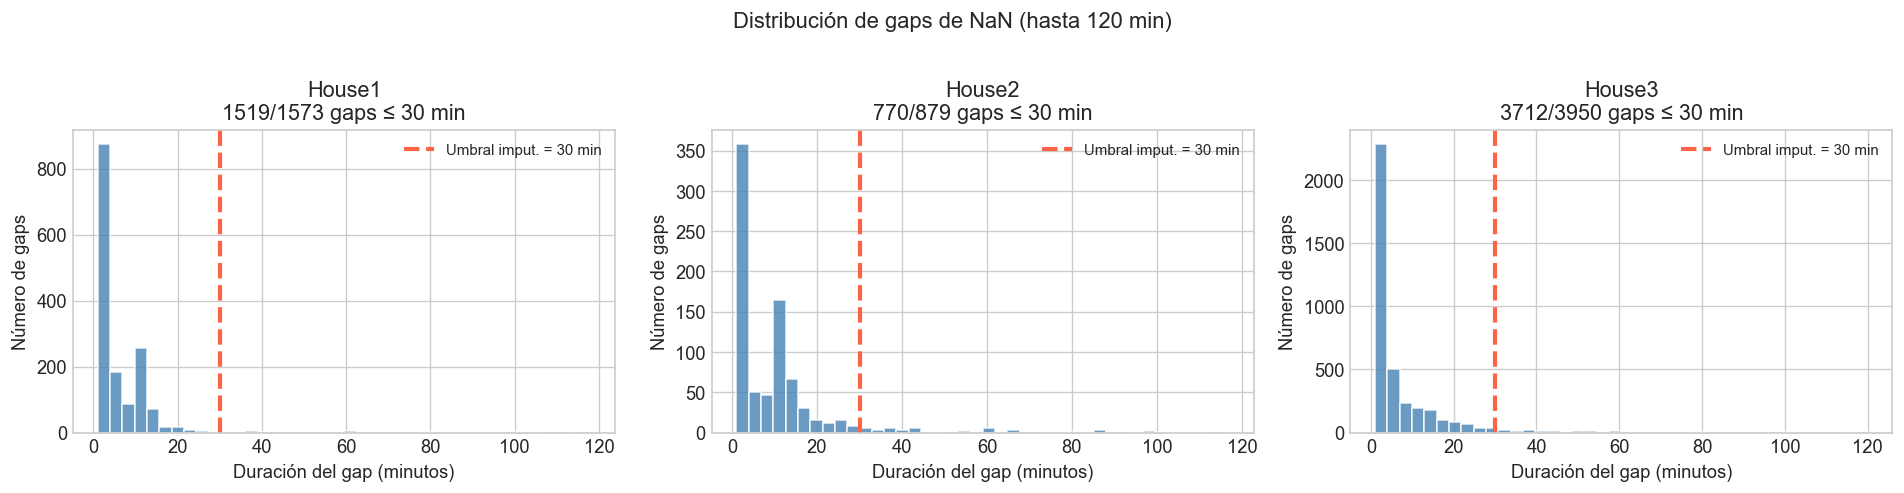

In [8]:
# ============================================================
# Análisis de la distribución de gaps (tamaño de los huecos)
# antes de decidir el umbral de imputación
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (hogar, df) in zip(axes, datos_1min.items()):
    serie = df['Aggregate']

    # Calcular longitud de cada gap (bloque de NaN consecutivos)
    es_nan = serie.isna()
    grupos = (es_nan != es_nan.shift()).cumsum()
    gaps   = es_nan.groupby(grupos).sum()
    gaps   = gaps[gaps > 0]  # solo grupos que son NaN

    # Histograma de tamaños de gap (en minutos)
    ax.hist(gaps[gaps <= 120], bins=40, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.axvline(UMBRAL_GAP_MIN, color='tomato', lw=2.5, linestyle='--',
               label=f'Umbral imput. = {UMBRAL_GAP_MIN} min')
    n_imputable = (gaps <= UMBRAL_GAP_MIN).sum()
    n_total_gap = len(gaps)
    ax.set_title(f'{hogar}\n{n_imputable}/{n_total_gap} gaps ≤ {UMBRAL_GAP_MIN} min')
    ax.set_xlabel('Duración del gap (minutos)')
    ax.set_ylabel('Número de gaps')
    ax.legend(fontsize=9)

plt.suptitle(f'Distribución de gaps de NaN (hasta 120 min)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '03_distribucion_gaps.png'), bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# Imputación por interpolación lineal para gaps <= UMBRAL_GAP_MIN
# Se aplica a todas las columnas de consumo simultáneamente.
#
# Método:
#   1. Identificar cada bloque de NaN consecutivos
#   2. Si el bloque tiene <= UMBRAL_GAP_MIN filas → interpolación lineal
#   3. Si el bloque tiene > UMBRAL_GAP_MIN filas → se deja como NaN
# ============================================================

def imputar_gaps_cortos(serie: pd.Series, umbral_min: int) -> pd.Series:
    """
    Interpola linealmente los gaps de NaN de longitud <= umbral_min.
    Los gaps más largos se mantienen como NaN.
    """
    serie = serie.copy()
    # Marcar cada bloque de NaN con un ID único
    es_nan = serie.isna()
    grupos = (es_nan != es_nan.shift()).cumsum()

    for grupo_id, bloque in serie.groupby(grupos):
        if bloque.isna().all() and len(bloque) <= umbral_min:
            # Interpolar solo este bloque corto
            idx_inicio = bloque.index[0]
            idx_fin    = bloque.index[-1]
            # Extender el rango para tener puntos de anclaje a ambos lados
            loc_inicio = serie.index.get_loc(idx_inicio)
            loc_fin    = serie.index.get_loc(idx_fin)
            if loc_inicio > 0 and loc_fin < len(serie) - 1:
                serie.iloc[loc_inicio:loc_fin + 1] = np.nan  # ya es NaN

    # Interpolación lineal solo en los gaps cortos ya marcados
    # usando limit_area='inside' para no extrapolar en los extremos
    serie_interp = serie.copy()
    es_nan_orig  = serie.isna()
    grupos2      = (es_nan_orig != es_nan_orig.shift()).cumsum()

    for grupo_id, bloque in serie.groupby(grupos2):
        if bloque.isna().all() and len(bloque) <= umbral_min:
            serie_interp = serie_interp.interpolate(method='linear', limit_area='inside')
            break  # interpolate actúa sobre toda la serie, solo necesitamos llamarlo una vez
        elif bloque.isna().all() and len(bloque) > umbral_min:
            # Asegurarnos de que el limit no rellene estos gaps
            pass

    # Aplicar interpolación con limit para no rellenar gaps largos
    serie_final = serie.interpolate(
        method='linear',
        limit=umbral_min,
        limit_area='inside'
    )
    return serie_final


datos_limpios  = {}
resumen_imput  = []

for hogar, df in datos_1min.items():
    df_imput = df.copy()

    nan_antes = df_imput['Aggregate'].isna().sum()

    # Aplicar imputación a todas las columnas de consumo
    for col in COLS_CONSUMO:
        df_imput[col] = imputar_gaps_cortos(df_imput[col], UMBRAL_GAP_MIN)

    nan_despues     = df_imput['Aggregate'].isna().sum()
    nan_imputados   = nan_antes - nan_despues
    pct_nan_final   = nan_despues / len(df_imput) * 100

    datos_limpios[hogar] = df_imput

    resumen_imput.append({
        'Hogar'              : hogar,
        'NaN antes imput.'   : f'{nan_antes:,}',
        'NaN imputados'      : f'{nan_imputados:,}',
        'NaN restantes'      : f'{nan_despues:,}',
        '% NaN final'        : f'{pct_nan_final:.2f}%',
    })

df_resumen_imput = pd.DataFrame(resumen_imput).set_index('Hogar')
print(f'=== Resultado tras imputación (umbral {UMBRAL_GAP_MIN} min) ===')
display(df_resumen_imput)

=== Resultado tras imputación (umbral 30 min) ===


,NaN antes imput.,NaN imputados,NaN restantes,% NaN final
Hogar,,,,
House1,"119,993","9,313","110,680",12.03%
House2,"219,633","8,989","210,644",23.69%
House3,"136,345","26,339","110,006",12.43%


## 7. Resumen comparativo antes/después <a id='7'></a>

In [10]:
# ============================================================
# Tabla resumen del proceso de limpieza completo
# ============================================================

resumen_final = []

for hogar in HOGARES:
    df_orig   = datos_raw[hogar]
    df_final  = datos_limpios[hogar]
    consumo_o = df_orig['Aggregate']
    consumo_f = df_final['Aggregate'].dropna()

    resumen_final.append({
        'Hogar'                : hogar,
        'Filas originales'     : f'{len(df_orig):,}',
        'Filas finales (1 min)': f'{len(df_final):,}',
        'Media orig. (W)'      : f'{consumo_o.mean():.1f}',
        'Media final (W)'      : f'{consumo_f.mean():.1f}',
        'Máx orig. (W)'        : f'{consumo_o.max():,.0f}',
        'Máx final (W)'        : f'{consumo_f.max():,.0f}',
        '% NaN restante'       : f"{df_final['Aggregate'].isna().mean()*100:.2f}%",
    })

df_resumen_final = pd.DataFrame(resumen_final).set_index('Hogar')
print('=== RESUMEN COMPLETO DEL PROCESO DE LIMPIEZA ===')
display(df_resumen_final.T)

# Guardar CSV
df_resumen_final.to_csv(os.path.join(RUTA_MET, '03_resumen_limpieza.csv'))
print('\nCSV guardado: resultados/metricas/03_resumen_limpieza.csv')

=== RESUMEN COMPLETO DEL PROCESO DE LIMPIEZA ===


Hogar,House1,House2,House3
Filas originales,"6,960,008","5,733,526","6,994,594"
Filas finales (1 min),"920,091","889,078","885,095"
Media orig. (W),481.1,465.1,678.5
Media final (W),482.1,461.4,686.6
Máx orig. (W),"29,159","24,595","65,836"
Máx final (W),"13,763","14,294","12,628"
% NaN restante,12.03%,23.69%,12.43%



CSV guardado: resultados/metricas/03_resumen_limpieza.csv


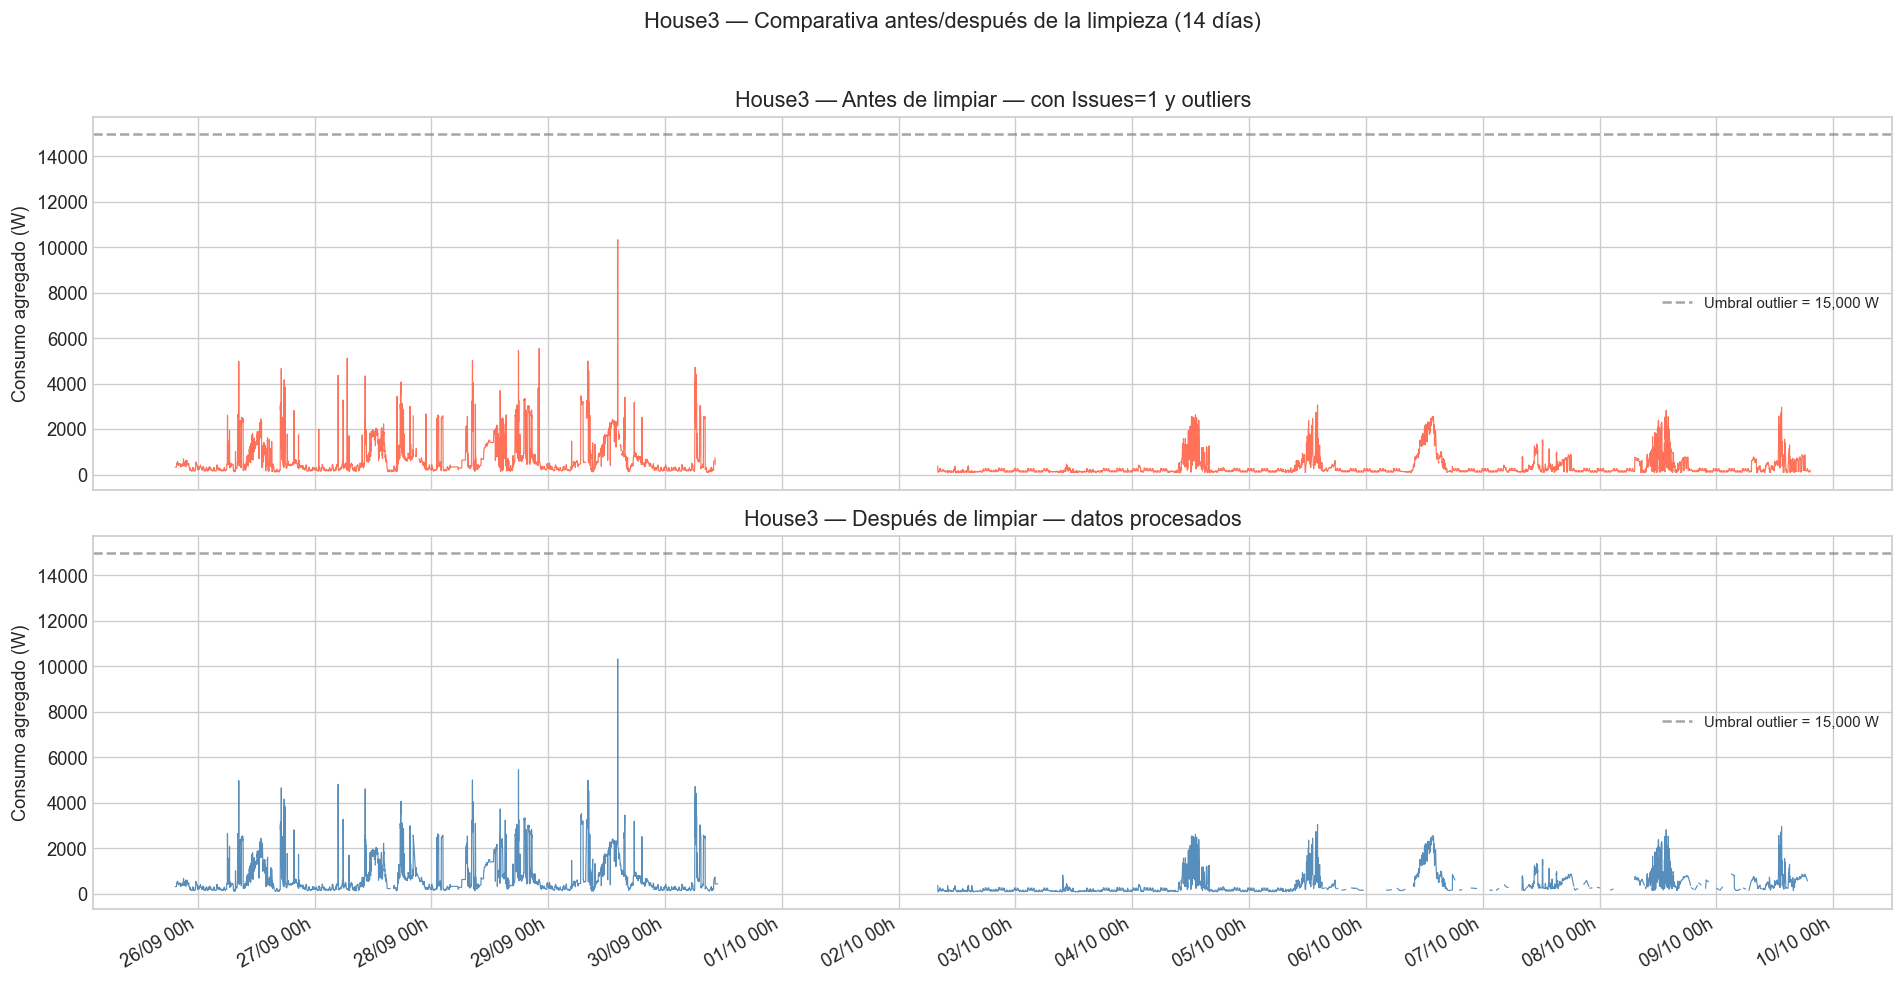

In [11]:
# ============================================================
# Figura comparativa: consumo agregado antes y después de limpiar
# Se muestra House3 (el más problemático) — primeros 14 días
# ============================================================

hogar_ejemplo = 'House3'
inicio        = datos_raw[hogar_ejemplo].index.min()
fin_14d       = inicio + pd.Timedelta(days=14)

# Serie original a 1 min (sin limpiar)
serie_orig = datos_raw[hogar_ejemplo]['Aggregate'].resample('1min').mean()
# Serie limpia
serie_limpia = datos_limpios[hogar_ejemplo]['Aggregate']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, serie, titulo, color in [
    (axes[0], serie_orig,   'Antes de limpiar — con Issues=1 y outliers', 'tomato'),
    (axes[1], serie_limpia, 'Después de limpiar — datos procesados', 'steelblue'),
]:
    segmento = serie.loc[inicio:fin_14d]
    ax.plot(segmento.index, segmento.values, color=color, lw=0.7, alpha=0.9)
    ax.axhline(UMBRAL_OUTLIER_W, color='gray', lw=1.5, linestyle='--',
               alpha=0.7, label=f'Umbral outlier = {UMBRAL_OUTLIER_W:,} W')
    ax.set_title(f'{hogar_ejemplo} — {titulo}')
    ax.set_ylabel('Consumo agregado (W)')
    ax.legend(fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
axes[1].xaxis.set_major_locator(mdates.DayLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle(f'{hogar_ejemplo} — Comparativa antes/después de la limpieza (14 días)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '03_comparativa_antes_despues.png'), bbox_inches='tight')
plt.show()

## 8. Guardado de datos procesados <a id='8'></a>

In [12]:
# ============================================================
# Guardar los DataFrames limpios como CSV en datos/processed/
# Formato: índice temporal + columnas de consumo + columna 'hogar'
# Nombre: house1_1min_limpio.csv, house2_1min_limpio.csv, etc.
# ============================================================

print('=== Guardando datos procesados en datos/processed/ ===')

for hogar, df in datos_limpios.items():
    nombre_archivo = f"{hogar.lower()}_1min_limpio.csv"
    ruta_salida    = os.path.join(RUTA_PROCESSED, nombre_archivo)

    df.to_csv(ruta_salida)

    tam_mb = os.path.getsize(ruta_salida) / 1024**2
    print(f'  OK  {nombre_archivo}  ({len(df):,} filas | {tam_mb:.1f} MB)')

print('\nTodos los archivos guardados correctamente.')

=== Guardando datos procesados en datos/processed/ ===


  OK  house1_1min_limpio.csv  (920,091 filas | 64.7 MB)


  OK  house2_1min_limpio.csv  (889,078 filas | 54.5 MB)


  OK  house3_1min_limpio.csv  (885,095 filas | 60.8 MB)

Todos los archivos guardados correctamente.


## 9. Verificación final <a id='9'></a>

In [13]:
# ============================================================
# Verificación de integridad de los datos procesados:
#   - Máximo de Aggregate no supera el umbral
#   - No hay valores negativos
#   - El porcentaje de NaN es razonable
#   - Los archivos CSV se han guardado correctamente
# ============================================================

print('=== VERIFICACIÓN FINAL DE LOS DATOS PROCESADOS ===')
print(f'  Umbral máximo esperado: {UMBRAL_OUTLIER_W:,} W\n')

todos_ok = True

for hogar, df in datos_limpios.items():
    consumo     = df['Aggregate'].dropna()
    max_val     = consumo.max()
    n_negativos = (consumo < 0).sum()
    pct_nan     = df['Aggregate'].isna().mean() * 100
    archivo_ok  = os.path.exists(
        os.path.join(RUTA_PROCESSED, f"{hogar.lower()}_1min_limpio.csv")
    )

    check_max  = '✓' if max_val <= UMBRAL_OUTLIER_W else '✗'
    check_neg  = '✓' if n_negativos == 0            else '✗'
    check_nan  = '✓' if pct_nan < 20                else '⚠'
    check_file = '✓' if archivo_ok                  else '✗'

    if '✗' in [check_max, check_neg, check_file]:
        todos_ok = False

    print(f'  {hogar}:')
    print(f'    {check_max} Máximo Aggregate   : {max_val:,.1f} W  (límite: {UMBRAL_OUTLIER_W:,} W)')
    print(f'    {check_neg} Valores negativos   : {n_negativos}')
    print(f'    {check_nan} % NaN restante       : {pct_nan:.2f}%')
    print(f'    {check_file} Archivo CSV guardado : {hogar.lower()}_1min_limpio.csv')
    print()

print('=== ' + ('NOTEBOOK 03 COMPLETADO CORRECTAMENTE ✓' if todos_ok else 'REVISAR ERRORES ✗') + ' ===')
print('\nPróximo paso: Notebook 04 — Feature Engineering')
print('  - Variables temporales (hora, día, mes, estación)')
print('  - Lags y medias móviles')
print('  - Variables cíclicas (sin/cos)')
print('  - Indicador de festivos UK')

=== VERIFICACIÓN FINAL DE LOS DATOS PROCESADOS ===
  Umbral máximo esperado: 15,000 W

  House1:
    ✓ Máximo Aggregate   : 13,763.3 W  (límite: 15,000 W)
    ✓ Valores negativos   : 0
    ✓ % NaN restante       : 12.03%
    ✓ Archivo CSV guardado : house1_1min_limpio.csv

  House2:
    ✓ Máximo Aggregate   : 14,294.0 W  (límite: 15,000 W)
    ✓ Valores negativos   : 0
    ⚠ % NaN restante       : 23.69%
    ✓ Archivo CSV guardado : house2_1min_limpio.csv

  House3:
    ✓ Máximo Aggregate   : 12,628.0 W  (límite: 15,000 W)
    ✓ Valores negativos   : 0
    ✓ % NaN restante       : 12.43%
    ✓ Archivo CSV guardado : house3_1min_limpio.csv

=== NOTEBOOK 03 COMPLETADO CORRECTAMENTE ✓ ===

Próximo paso: Notebook 04 — Feature Engineering
  - Variables temporales (hora, día, mes, estación)
  - Lags y medias móviles
  - Variables cíclicas (sin/cos)
  - Indicador de festivos UK


In [14]:
# ============================================================
# Inventario de figuras y archivos generados por este notebook
# ============================================================

figuras = [
    '03_issues_temporales_house3.png',
    '03_outliers_histograma.png',
    '03_distribucion_gaps.png',
    '03_comparativa_antes_despues.png',
]

print('=== Figuras exportadas a resultados/figuras/ ===')
for f in figuras:
    existe = os.path.exists(os.path.join(RUTA_FIGS, f))
    print(f'  {"OK" if existe else "FALTA":5s}  {f}')

print('\n=== CSVs exportados a resultados/metricas/ ===')
print(f'  {"OK" if os.path.exists(os.path.join(RUTA_MET, "03_resumen_limpieza.csv")) else "FALTA":5s}  03_resumen_limpieza.csv')

print('\n=== Datos procesados en datos/processed/ ===')
for hogar in HOGARES:
    nombre = f'{hogar.lower()}_1min_limpio.csv'
    existe = os.path.exists(os.path.join(RUTA_PROCESSED, nombre))
    print(f'  {"OK" if existe else "FALTA":5s}  {nombre}')

=== Figuras exportadas a resultados/figuras/ ===
  OK     03_issues_temporales_house3.png
  OK     03_outliers_histograma.png
  OK     03_distribucion_gaps.png
  OK     03_comparativa_antes_despues.png

=== CSVs exportados a resultados/metricas/ ===
  OK     03_resumen_limpieza.csv

=== Datos procesados en datos/processed/ ===
  OK     house1_1min_limpio.csv
  OK     house2_1min_limpio.csv
  OK     house3_1min_limpio.csv
